# Results Analysis

Load result CSV files, identify the best method in each setting, and summarize error, rank, kernel, PCA, and timing behavior.

In [47]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)


In [48]:
# Configuration
# Leave RESULT_FILES empty to load every Framework1/Framework2 results_*.csv file.
RESULT_FILES = []

RESULT_GLOBS = [
    #'Framework1/results_*.csv',
    #'Framework2/results_*.csv',
    'resultsFramework2onFramework1/results_*.csv'
]

# A setting is one comparison group. Methods are ranked only within the same setting.
SETTING_COLUMNS = ['framework', 'pde', 'task_mode', 'split', 'pca']

ERROR_COLUMN = 'mean_relative_error'
TIME_COLUMN = 'train_time_seconds'


In [49]:
def discover_result_files(result_files=None, result_globs=None):
    if result_files:
        paths = [Path(path) for path in result_files]
    else:
        paths = []
        for pattern in result_globs or []:
            paths.extend(Path('.').glob(pattern))
    return sorted(dict.fromkeys(paths))


def infer_framework(path):
    parts = Path(path).parts
    if 'Framework1' in parts:
        return 'Framework1'
    if 'Framework2' in parts:
        return 'Framework2'
    return 'unknown'


def load_results(paths):
    frames = []
    missing = []
    for path in paths:
        path = Path(path)
        if not path.exists():
            missing.append(path)
            continue
        df = pd.read_csv(path)
        df['source_file'] = str(path)
        df['framework'] = infer_framework(path)
        frames.append(df)
    if missing:
        print('Missing files:')
        for path in missing:
            print(' -', path)
    if not frames:
        raise FileNotFoundError('No result CSV files were loaded.')
    df = pd.concat(frames, ignore_index=True, sort=False)
    return clean_results(df)


def clean_results(df):
    df = df.copy()
    numeric_columns = [
        'n_train', 'n_eval', 'ics_per_param', 'mean_relative_error', 'std_relative_error',
        'x_model_dim', 'coef_model_dim', 'y_model_dim', 'fw1_x_model_dim', 'fw1_y_model_dim',
        'train_time_seconds', 'predict_time_seconds', 'length_scale', 'alpha', 'nu',
        'coef_length_scale', 'coef_nu', 'state_length_scale', 'state_nu',
    ]
    for column in numeric_columns:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors='coerce')

    if 'task_mode' not in df.columns:
        df['task_mode'] = 'unknown'
    if 'pca' in df.columns:
        df['pca'] = df['pca'].astype(str).str.lower().map({'true': True, 'false': False}).fillna(df['pca'])
    else:
        df['pca'] = False

    for column in SETTING_COLUMNS:
        if column not in df.columns:
            df[column] = np.nan

    df['method_label'] = df['method'].astype(str) + ' | ' + df['kernel'].astype(str)
    df['setting_id'] = df[SETTING_COLUMNS].apply(lambda row: ' | '.join(map(str, row.to_list())), axis=1)
    return df


HIDDEN_DISPLAY_COLUMNS = ['x_model_dim', 'coef_model_dim', 'y_model_dim', 'fw1_x_model_dim', 'fw1_y_model_dim']


def without_model_dim_columns(df):
    return df.drop(columns=[column for column in HIDDEN_DISPLAY_COLUMNS if column in df.columns])


PERCENT_COLUMNS = ['mean_relative_error', 'std_relative_error', 'best_error_in_setting', 'error_gap_to_best']


def with_percent_errors(df):
    formatted = without_model_dim_columns(df).copy()
    for column in PERCENT_COLUMNS:
        if column in formatted.columns:
            formatted[column] = (formatted[column] * 100).map(lambda value: f'{value:.3f}%' if pd.notna(value) else value)
    if 'error_ratio_to_best' in formatted.columns:
        formatted['error_ratio_to_best'] = formatted['error_ratio_to_best'].map(lambda value: f'{value:.3f}x' if pd.notna(value) else value)
    return formatted



def percent_table(df, ratio_columns=None):
    ratio_columns = set(ratio_columns or [])
    formatted = df.copy()
    for column in formatted.columns:
        if column in ratio_columns:
            formatted[column] = formatted[column].map(lambda value: f'{value:.3f}x' if pd.notna(value) else value)
        elif pd.api.types.is_numeric_dtype(formatted[column]):
            formatted[column] = (formatted[column] * 100).map(lambda value: f'{value:.3f}%' if pd.notna(value) else value)
    return formatted


paths = discover_result_files(RESULT_FILES, RESULT_GLOBS)
print(f'Found {len(paths)} result files:')
for path in paths:
    print(' -', path)

results = load_results(paths)
print('\nRows:', len(results))
display(with_percent_errors(results.head()))


Found 5 result files:
 - resultsFramework2onFramework1/results_Conservation_law_sample_no_pca.csv
 - resultsFramework2onFramework1/results_DiffReacAdv_sample_no_pca.csv
 - resultsFramework2onFramework1/results_Nonlinear_Klein_Gordon_sample_no_pca.csv
 - resultsFramework2onFramework1/results_Param_DiffReac_sample_no_pca.csv
 - resultsFramework2onFramework1/results_Parametric_Wave_sample_no_pca.csv

Rows: 32


,pde,task_mode,method,kernel,split,n_train,n_eval,ics_per_param,mean_relative_error,std_relative_error,pca,train_time_seconds,predict_time_seconds,length_scale,alpha,nu,coef_length_scale,coef_nu,state_length_scale,state_nu,source_file,framework,method_label,setting_id
0,Conservation_law,sample,vanilla,RBF,test,6400,1600,NaN,3.719%,3.116%,False,6.064482,0.753272,100.0,1.000000e-10,NaN,NaN,NaN,NaN,NaN,resultsFramework2onFramework1/results_Conserva...,unknown,vanilla | RBF,unknown | Conservation_law | sample | test | F...
1,Conservation_law,sample,vanilla,RBF,ood,6400,800,NaN,8.481%,6.635%,False,6.064482,0.376541,100.0,1.000000e-10,NaN,NaN,NaN,NaN,NaN,resultsFramework2onFramework1/results_Conserva...,unknown,vanilla | RBF,unknown | Conservation_law | sample | ood | False
2,Conservation_law,sample,vanilla,Matern,test,6400,1600,NaN,3.719%,3.116%,False,5.818523,0.782669,1.0,1.000000e-10,2.5,NaN,NaN,NaN,NaN,resultsFramework2onFramework1/results_Conserva...,unknown,vanilla | Matern,unknown | Conservation_law | sample | test | F...
3,Conservation_law,sample,vanilla,Matern,ood,6400,800,NaN,8.481%,6.635%,False,5.818523,0.390727,1.0,1.000000e-10,2.5,NaN,NaN,NaN,NaN,resultsFramework2onFramework1/results_Conserva...,unknown,vanilla | Matern,unknown | Conservation_law | sample | ood | False
4,Conservation_law,sample,product_gpr,Matern x Matern,test,6400,1600,NaN,0.014%,0.022%,False,6.349399,0.849733,NaN,1.000000e-10,NaN,1.0,2.5,1.0,2.5,resultsFramework2onFramework1/results_Conserva...,unknown,product_gpr | Matern x Matern,unknown | Conservation_law | sample | test | F...


In [50]:
# Best method in each setting
sort_columns = SETTING_COLUMNS + [ERROR_COLUMN]
ranked = results.sort_values(sort_columns).copy()
ranked['rank_in_setting'] = ranked.groupby('setting_id')[ERROR_COLUMN].rank(method='min', ascending=True)
ranked['best_error_in_setting'] = ranked.groupby('setting_id')[ERROR_COLUMN].transform('min')
ranked['error_ratio_to_best'] = ranked[ERROR_COLUMN] / ranked['best_error_in_setting']
ranked['error_gap_to_best'] = ranked[ERROR_COLUMN] - ranked['best_error_in_setting']

best_by_setting = ranked.loc[ranked.groupby('setting_id')[ERROR_COLUMN].idxmin()].copy()
best_columns = SETTING_COLUMNS + ['method', 'kernel', 'method_label', ERROR_COLUMN, 'std_relative_error', 'n_train', 'n_eval', 'train_time_seconds', 'predict_time_seconds', 'source_file']
best_columns = [column for column in best_columns if column in best_by_setting.columns]

print(f'Best rows across {best_by_setting.shape[0]} settings')
display(with_percent_errors(best_by_setting[best_columns].sort_values(SETTING_COLUMNS)))


Best rows across 8 settings


,framework,pde,task_mode,split,pca,method,kernel,method_label,mean_relative_error,std_relative_error,n_train,n_eval,train_time_seconds,predict_time_seconds,source_file
5,unknown,Conservation_law,sample,ood,False,product_gpr,Matern x Matern,product_gpr | Matern x Matern,0.772%,1.543%,6400,800,6.349399,0.430367,resultsFramework2onFramework1/results_Conserva...
4,unknown,Conservation_law,sample,test,False,product_gpr,Matern x Matern,product_gpr | Matern x Matern,0.014%,0.022%,6400,1600,6.349399,0.849733,resultsFramework2onFramework1/results_Conserva...
13,unknown,DiffReacAdv,sample,ood,False,product_gpr,Matern x Matern,product_gpr | Matern x Matern,5.327%,4.594%,6400,800,6.381918,0.429670,resultsFramework2onFramework1/results_DiffReac...
14,unknown,DiffReacAdv,sample,test,False,product_gpr,RBF x RBF,product_gpr | RBF x RBF,0.779%,0.515%,6400,1600,6.146338,0.795060,resultsFramework2onFramework1/results_DiffReac...
21,unknown,Nonlinear_Klein_Gordon,sample,ood,False,product_gpr,Matern x Matern,product_gpr | Matern x Matern,6.718%,9.126%,6400,800,13.557514,1.320505,resultsFramework2onFramework1/results_Nonlinea...
20,unknown,Nonlinear_Klein_Gordon,sample,test,False,product_gpr,Matern x Matern,product_gpr | Matern x Matern,0.209%,0.190%,6400,1600,13.557514,2.619025,resultsFramework2onFramework1/results_Nonlinea...
26,unknown,Param_DiffReac,sample,test,False,product_gpr,Matern x Matern,product_gpr | Matern x Matern,0.064%,0.146%,6400,1600,7.411045,1.112999,resultsFramework2onFramework1/results_Param_Di...
30,unknown,Parametric_Wave,sample,test,False,product_gpr,Matern x Matern,product_gpr | Matern x Matern,2.631%,5.858%,6400,1600,6.900967,0.968357,resultsFramework2onFramework1/results_Parametr...


In [51]:
# Win rates and average ranks
win_counts = (
    best_by_setting.groupby(['framework', 'task_mode', 'split', 'method_label'])
    .size()
    .rename('wins')
    .reset_index()
    .sort_values(['framework', 'task_mode', 'split', 'wins'], ascending=[True, True, True, False])
)

rank_summary = (
    ranked.groupby(['framework', 'task_mode', 'split', 'method_label'])
    .agg(
        appearances=('method_label', 'size'),
        mean_rank=('rank_in_setting', 'mean'),
        median_rank=('rank_in_setting', 'median'),
        mean_error=(ERROR_COLUMN, 'mean'),
        median_error=(ERROR_COLUMN, 'median'),
        mean_error_ratio_to_best=('error_ratio_to_best', 'mean'),
        median_error_ratio_to_best=('error_ratio_to_best', 'median'),
    )
    .reset_index()
    .sort_values(['framework', 'task_mode', 'split', 'mean_rank', 'median_error'])
)

display(win_counts)
display(with_percent_errors(rank_summary))


,framework,task_mode,split,method_label,wins
0,unknown,sample,ood,product_gpr | Matern x Matern,3
1,unknown,sample,test,product_gpr | Matern x Matern,4
2,unknown,sample,test,product_gpr | RBF x RBF,1


,framework,task_mode,split,method_label,appearances,mean_rank,median_rank,mean_error,median_error,mean_error_ratio_to_best,median_error_ratio_to_best
0,unknown,sample,ood,product_gpr | Matern x Matern,3,1.000000,1.0,0.042726,0.053274,1.000000,1.000000
1,unknown,sample,ood,product_gpr | RBF x RBF,3,2.000000,2.0,0.065486,0.063958,1.840101,1.667350
2,unknown,sample,ood,vanilla | Matern,3,3.333333,3.0,0.247109,0.204154,7.182108,6.733463
3,unknown,sample,ood,vanilla | RBF,3,3.666667,4.0,0.247109,0.204154,7.182114,6.733472
4,unknown,sample,test,product_gpr | Matern x Matern,5,1.200000,1.0,0.007410,0.002089,1.001959,1.000000
5,unknown,sample,test,product_gpr | RBF x RBF,5,1.800000,2.0,0.021814,0.003664,3.191560,3.559349
6,unknown,sample,test,vanilla | Matern,5,3.200000,3.0,0.209290,0.120020,107.423118,107.549086
7,unknown,sample,test,vanilla | RBF,5,3.800000,4.0,0.209291,0.120022,107.423347,107.549500


In [52]:
# Error table for quick PDE-by-PDE comparison, displayed as percentages
error_pivot = ranked.pivot_table(
    index=['framework', 'pde', 'task_mode', 'split', 'pca'],
    columns='method_label',
    values=ERROR_COLUMN,
    aggfunc='min',
)
display(percent_table(error_pivot))


method_label                                           product_gpr | Matern x Matern product_gpr | RBF x RBF vanilla | Matern vanilla | RBF
framework pde                    task_mode split pca                                                                                       
unknown   Conservation_law       sample    ood   False                        0.772%                  2.049%           8.481%        8.481%
                                           test  False                        0.014%                  0.064%           3.719%        3.719%
          DiffReacAdv            sample    ood   False                        5.327%                  6.396%          20.415%       20.415%
                                           test  False                        0.787%                  0.779%          12.002%       12.002%
          Nonlinear_Klein_Gordon sample    ood   False                        6.718%                 11.201%          45.236%       45.236%
                                           test  False                        0.209%                  0.366%          28.587%       28.587%
          Param_DiffReac         sample    test  False                        0.064%                  0.332%           6.836%        6.836%
          Parametric_Wave        sample    test  False                        2.631%                  9.365%          53.501%       53.501%

In [53]:
# Timing summaries
timing_columns = [column for column in ['train_time_seconds', 'predict_time_seconds'] if column in ranked.columns]
if timing_columns:
    timing_summary = (
        ranked.groupby(['framework', 'task_mode', 'method_label'])[timing_columns]
        .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    )
    display(timing_summary)

    time_error = ranked[[
        'framework', 'pde', 'task_mode', 'split', 'pca', 'method_label', ERROR_COLUMN,
        'train_time_seconds', 'predict_time_seconds', 'error_ratio_to_best'
    ]].sort_values(['framework', 'pde', 'task_mode', 'split', ERROR_COLUMN])
    display(with_percent_errors(time_error))
else:
    print('No timing columns found.')


train_time_seconds                                                    predict_time_seconds            \
                                                               count      mean    median       std       min        max                count      mean   
framework task_mode method_label                                                                                                                         
unknown   sample    product_gpr | Matern x Matern                  8  8.361209  6.641443  3.228627  6.349399  13.557514                    8  1.072059   
                    product_gpr | RBF x RBF                        8  6.340859  6.148667  0.417341  6.095095   7.250710                    8  0.707830   
                    vanilla | Matern                               8  5.838050  5.833555  0.020383  5.818523   5.878025                    8  0.631168   
                    vanilla | RBF                                  8  5.862572  5.825393  0.129766  5.733259   6.064482                    8  0.612407   

                                                                                           
                                                     median       std       min       max  
framework task_mode method_label                                                           
unknown   sample    product_gpr | Matern x Matern  0.909045  0.696143  0.429670  2.619025  
                    product_gpr | RBF x RBF        0.796160  0.273805  0.398680  1.115745  
                    vanilla | Matern               0.770756  0.199960  0.386705  0.782971  
                    vanilla | RBF                  0.744103  0.194626  0.372744  0.765138

,framework,pde,task_mode,split,pca,method_label,mean_relative_error,train_time_seconds,predict_time_seconds,error_ratio_to_best
5,unknown,Conservation_law,sample,ood,False,product_gpr | Matern x Matern,0.772%,6.349399,0.430367,1.000x
7,unknown,Conservation_law,sample,ood,False,product_gpr | RBF x RBF,2.049%,6.150996,0.398680,2.652x
3,unknown,Conservation_law,sample,ood,False,vanilla | Matern,8.481%,5.818523,0.390727,10.981x
1,unknown,Conservation_law,sample,ood,False,vanilla | RBF,8.481%,6.064482,0.376541,10.981x
4,unknown,Conservation_law,sample,test,False,product_gpr | Matern x Matern,0.014%,6.349399,0.849733,1.000x
6,unknown,Conservation_law,sample,test,False,product_gpr | RBF x RBF,0.064%,6.150996,0.801618,4.424x
0,unknown,Conservation_law,sample,test,False,vanilla | RBF,3.719%,6.064482,0.753272,256.982x
2,unknown,Conservation_law,sample,test,False,vanilla | Matern,3.719%,5.818523,0.782669,256.982x
13,unknown,DiffReacAdv,sample,ood,False,product_gpr | Matern x Matern,5.327%,6.381918,0.429670,1.000x
15,unknown,DiffReacAdv,sample,ood,False,product_gpr | RBF x RBF,6.396%,6.146338,0.404680,1.201x


In [54]:
# Kernel comparison: RBF vs Matern within each method family when both exist
kernel_compare = ranked.copy()
kernel_compare['kernel_family'] = np.where(kernel_compare['kernel'].str.contains('RBF', case=False, na=False), 'RBF', 'Matern')
kernel_pivot = kernel_compare.pivot_table(
    index=SETTING_COLUMNS + ['method'],
    columns='kernel_family',
    values=ERROR_COLUMN,
    aggfunc='min',
)
if {'RBF', 'Matern'}.issubset(kernel_pivot.columns):
    kernel_pivot['RBF_minus_Matern'] = kernel_pivot['RBF'] - kernel_pivot['Matern']
    kernel_pivot['winner'] = np.where(kernel_pivot['RBF_minus_Matern'] < 0, 'RBF', 'Matern')
display(percent_table(kernel_pivot) if isinstance(kernel_pivot, pd.DataFrame) else kernel_pivot)


kernel_family                                                        Matern      RBF RBF_minus_Matern  winner
framework pde                    task_mode split pca   method                                                
unknown   Conservation_law       sample    ood   False product_gpr   0.772%   2.049%           1.276%  Matern
                                                       vanilla       8.481%   8.481%           0.000%  Matern
                                           test  False product_gpr   0.014%   0.064%           0.050%  Matern
                                                       vanilla       3.719%   3.719%          -0.000%     RBF
          DiffReacAdv            sample    ood   False product_gpr   5.327%   6.396%           1.068%  Matern
                                                       vanilla      20.415%  20.415%          -0.000%     RBF
                                           test  False product_gpr   0.787%   0.779%          -0.008%     RBF
                                                       vanilla      12.002%  12.002%           0.000%  Matern
          Nonlinear_Klein_Gordon sample    ood   False product_gpr   6.718%  11.201%           4.483%  Matern
                                                       vanilla      45.236%  45.236%           0.000%  Matern
                                           test  False product_gpr   0.209%   0.366%           0.158%  Matern
                                                       vanilla      28.587%  28.587%           0.000%  Matern
          Param_DiffReac         sample    test  False product_gpr   0.064%   0.332%           0.268%  Matern
                                                       vanilla       6.836%   6.836%           0.000%  Matern
          Parametric_Wave        sample    test  False product_gpr   2.631%   9.365%           6.734%  Matern
                                                       vanilla      53.501%  53.501%           0.000%  Matern

In [55]:
# PCA comparison, only meaningful when both PCA and non-PCA runs exist for the same method/setting.
pca_compare = ranked.pivot_table(
    index=['framework', 'pde', 'task_mode', 'split', 'method_label'],
    columns='pca',
    values=ERROR_COLUMN,
    aggfunc='min',
)
if True in pca_compare.columns and False in pca_compare.columns:
    pca_compare['pca_minus_no_pca'] = pca_compare[True] - pca_compare[False]
    pca_compare['pca_error_ratio'] = pca_compare[True] / pca_compare[False]
display(percent_table(pca_compare, ratio_columns=['pca_error_ratio']) if isinstance(pca_compare, pd.DataFrame) else pca_compare)


pca                                                                               False
framework pde                    task_mode split method_label                          
unknown   Conservation_law       sample    ood   product_gpr | Matern x Matern   0.772%
                                                 product_gpr | RBF x RBF         2.049%
                                                 vanilla | Matern                8.481%
                                                 vanilla | RBF                   8.481%
                                           test  product_gpr | Matern x Matern   0.014%
                                                 product_gpr | RBF x RBF         0.064%
                                                 vanilla | Matern                3.719%
                                                 vanilla | RBF                   3.719%
          DiffReacAdv            sample    ood   product_gpr | Matern x Matern   5.327%
                                                 product_gpr | RBF x RBF         6.396%
                                                 vanilla | Matern               20.415%
                                                 vanilla | RBF                  20.415%
                                           test  product_gpr | Matern x Matern   0.787%
                                                 product_gpr | RBF x RBF         0.779%
                                                 vanilla | Matern               12.002%
                                                 vanilla | RBF                  12.002%
          Nonlinear_Klein_Gordon sample    ood   product_gpr | Matern x Matern   6.718%
                                                 product_gpr | RBF x RBF        11.201%
                                                 vanilla | Matern               45.236%
                                                 vanilla | RBF                  45.236%
                                           test  product_gpr | Matern x Matern   0.209%
                                                 product_gpr | RBF x RBF         0.366%
                                                 vanilla | Matern               28.587%
                                                 vanilla | RBF                  28.587%
          Param_DiffReac         sample    test  product_gpr | Matern x Matern   0.064%
                                                 product_gpr | RBF x RBF         0.332%
                                                 vanilla | Matern                6.836%
                                                 vanilla | RBF                   6.836%
          Parametric_Wave        sample    test  product_gpr | Matern x Matern   2.631%
                                                 product_gpr | RBF x RBF         9.365%
                                                 vanilla | Matern               53.501%
                                                 vanilla | RBF                  53.501%

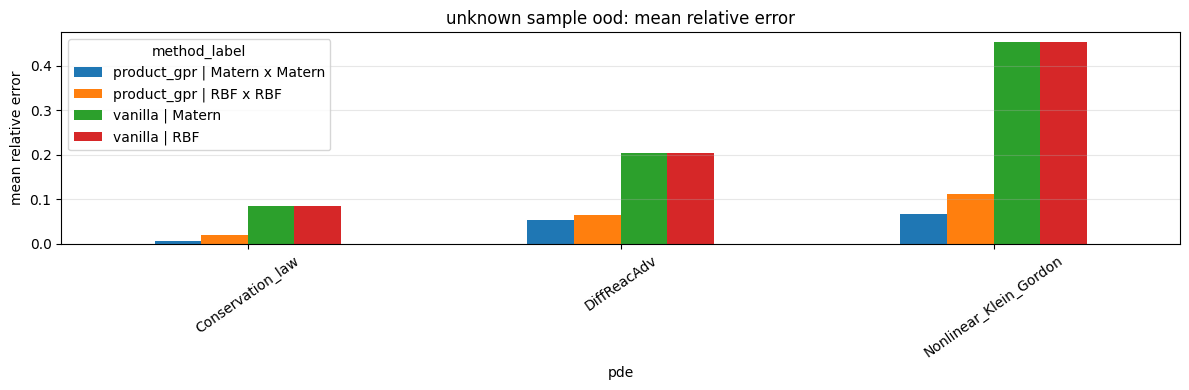

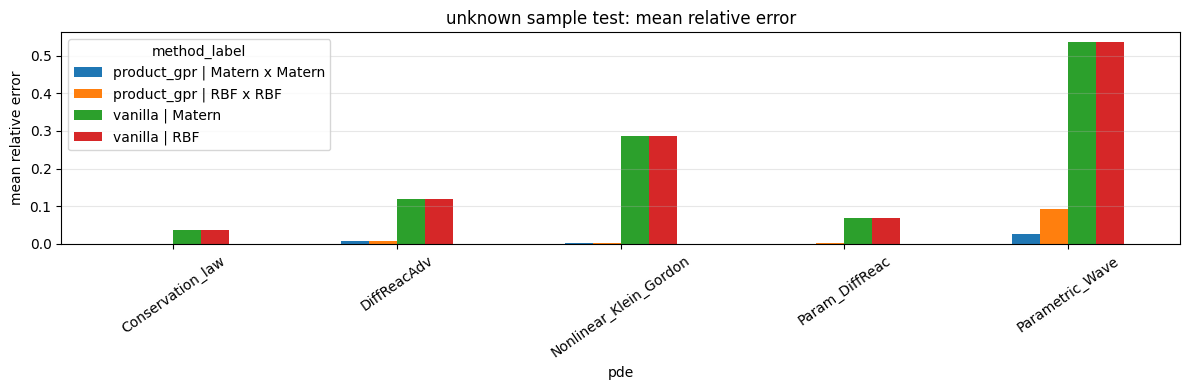

In [56]:
# Simple plots
plot_df = ranked.copy()
plot_df['setting_short'] = plot_df['framework'] + ' | ' + plot_df['pde'] + ' | ' + plot_df['split'].astype(str) + ' | pca=' + plot_df['pca'].astype(str)

for (framework, task_mode, split), group in plot_df.groupby(['framework', 'task_mode', 'split']):
    if group.empty:
        continue
    pivot = group.pivot_table(index='pde', columns='method_label', values=ERROR_COLUMN, aggfunc='min')
    ax = pivot.plot(kind='bar', figsize=(12, 4), rot=35)
    ax.set_title(f'{framework} {task_mode} {split}: mean relative error')
    ax.set_ylabel('mean relative error')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [57]:
# High-level written summary
print('Loaded files:', len(paths))
print('Total rows:', len(results))
print('Settings compared:', best_by_setting.shape[0])

overall_winners = best_by_setting['method_label'].value_counts().rename_axis('method_label').reset_index(name='wins')
print('\nOverall winners:')
display(overall_winners)

print('\nBest method by framework/task/split:')
display(win_counts)

print('\nLargest gaps to best, useful for spotting weak methods/settings:')
worst_gaps = ranked.sort_values('error_ratio_to_best', ascending=False)[[
    'framework', 'pde', 'task_mode', 'split', 'pca', 'method_label', ERROR_COLUMN, 'best_error_in_setting', 'error_ratio_to_best'
]].head(20)
display(with_percent_errors(worst_gaps))


Loaded files: 5
Total rows: 32
Settings compared: 8

Overall winners:


,method_label,wins
0,product_gpr | Matern x Matern,7
1,product_gpr | RBF x RBF,1



Best method by framework/task/split:


,framework,task_mode,split,method_label,wins
0,unknown,sample,ood,product_gpr | Matern x Matern,3
1,unknown,sample,test,product_gpr | Matern x Matern,4
2,unknown,sample,test,product_gpr | RBF x RBF,1



Largest gaps to best, useful for spotting weak methods/settings:


,framework,pde,task_mode,split,pca,method_label,mean_relative_error,best_error_in_setting,error_ratio_to_best
2,unknown,Conservation_law,sample,test,False,vanilla | Matern,3.719%,0.014%,256.982x
0,unknown,Conservation_law,sample,test,False,vanilla | RBF,3.719%,0.014%,256.982x
16,unknown,Nonlinear_Klein_Gordon,sample,test,False,vanilla | RBF,28.587%,0.209%,136.851x
18,unknown,Nonlinear_Klein_Gordon,sample,test,False,vanilla | Matern,28.587%,0.209%,136.850x
24,unknown,Param_DiffReac,sample,test,False,vanilla | RBF,6.836%,0.064%,107.549x
25,unknown,Param_DiffReac,sample,test,False,vanilla | Matern,6.836%,0.064%,107.549x
28,unknown,Parametric_Wave,sample,test,False,vanilla | RBF,53.501%,2.631%,20.334x
29,unknown,Parametric_Wave,sample,test,False,vanilla | Matern,53.501%,2.631%,20.334x
8,unknown,DiffReacAdv,sample,test,False,vanilla | RBF,12.002%,0.779%,15.400x
10,unknown,DiffReacAdv,sample,test,False,vanilla | Matern,12.002%,0.779%,15.400x


In [58]:
# Export selected tables as PNG images
EXPORT_DIR = Path('analysis_exports')
EXPORT_DIR.mkdir(exist_ok=True)


def format_percent_value(value, decimals=2):
    if pd.isna(value):
        return ''
    return f'{100 * value:.{decimals}f}%'


def format_ratio_value(value, decimals=2):
    if pd.isna(value):
        return ''
    return f'{value:.{decimals}f}x'


def map_dataframe(df, func):
    if hasattr(df, 'map'):
        return df.map(func)
    return df.apply(lambda column: column.map(func))


def flatten_columns(df):
    flattened = df.copy()
    if isinstance(flattened.columns, pd.MultiIndex):
        flattened.columns = [' | '.join(map(str, col)).strip() for col in flattened.columns]
    if isinstance(flattened.index, pd.MultiIndex):
        flattened = flattened.reset_index()
    else:
        flattened = flattened.reset_index()
    return flattened


def save_table_image(df, path, title=None, max_col_width=34, font_size=8):
    table_df = flatten_columns(df)
    table_df = table_df.astype(str)
    table_df.columns = [str(col)[:max_col_width] for col in table_df.columns]
    for column in table_df.columns:
        table_df[column] = table_df[column].map(lambda text: text[:max_col_width])

    n_rows, n_cols = table_df.shape
    fig_width = max(8, min(28, 1.45 * n_cols))
    fig_height = max(2.5, min(36, 0.36 * (n_rows + 2)))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=font_size + 4, pad=12)

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc='center',
        loc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, 1.25)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#e8eef7')
        elif row % 2 == 0:
            cell.set_facecolor('#f7f7f7')

    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved {path}')


# 1. Error pivot in percentages, 2 decimals.
error_pivot_export = map_dataframe(error_pivot.copy(), lambda value: format_percent_value(value, decimals=2))
save_table_image(
    error_pivot_export,
    EXPORT_DIR / 'error_pivot_percent.png',
    title='Mean Relative Error (%)',
)

# 2. Time/error table with error columns in percentages, 2 decimals.
time_error_export = time_error.copy()
for column in ['mean_relative_error', 'best_error_in_setting', 'error_gap_to_best']:
    if column in time_error_export.columns:
        time_error_export[column] = time_error_export[column].map(lambda value: format_percent_value(value, decimals=2))
if 'error_ratio_to_best' in time_error_export.columns:
    time_error_export['error_ratio_to_best'] = time_error_export['error_ratio_to_best'].map(lambda value: format_ratio_value(value, decimals=2))
for column in ['train_time_seconds', 'predict_time_seconds']:
    if column in time_error_export.columns:
        time_error_export[column] = time_error_export[column].map(lambda value: f'{value:.2f}' if pd.notna(value) else '')
save_table_image(
    without_model_dim_columns(time_error_export),
    EXPORT_DIR / 'time_error_table.png',
    title='Error and Timing Summary',
)

# 3. Win counts.
save_table_image(
    win_counts,
    EXPORT_DIR / 'win_counts.png',
    title='Win Counts',
)


Saved analysis_exports/error_pivot_percent.png
Saved analysis_exports/time_error_table.png
Saved analysis_exports/win_counts.png
